<a href="https://colab.research.google.com/github/progHYA/Haya-Albaqami---NLP-Project-SDAIA/blob/main/Haya_Albaqami_NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#مِداد

# Customer Review Sentiment Analysis

## Objective
The objective of this project is to develop an NLP model
that classifies customer reviews as positive or negative.

The project includes:
- Text preprocessing
- Exploratory data analysis
- Feature extraction using TF-IDF
- Machine learning classification
- Model evaluation
- Prediction on new reviews

# **Step 1 — Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# **Step 2 — Load the Dataset**

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
from google.colab import files

uploaded = files.upload()

Saving amazon_cells_labelled.txt to amazon_cells_labelled.txt


In [4]:
import pandas as pd

df = pd.read_csv(
    "amazon_cells_labelled.txt",
    sep="\t",
    header=None,
    names=["Review", "Sentiment"]
)

df.head()

,Review,Sentiment
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [5]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

df.info()

Number of rows: 1000
Number of columns: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     1000 non-null   object
 1   Sentiment  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


# **Step 3 — Check Missing Values**

In [6]:
df.isnull().sum()

,0
Review,0
Sentiment,0


In [7]:
df = df.dropna(subset=["Review", "Sentiment"])

In [8]:
df.isnull().sum()

,0
Review,0
Sentiment,0


# **Step 4 — Explore the Data**

In [9]:
print(df["Sentiment"].value_counts())

Sentiment
0    500
1    500
Name: count, dtype: int64


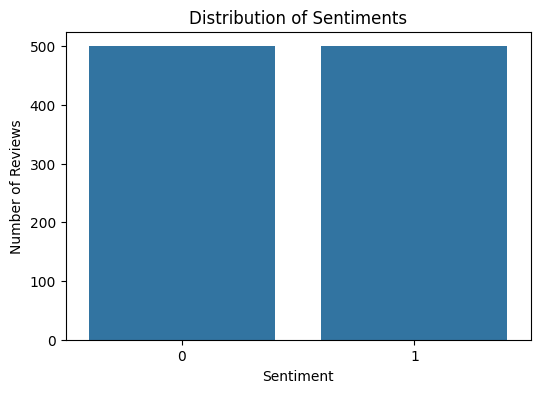

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

# **Step 5 — Text Cleaning**

In [11]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [12]:
df["Clean_Review"] = df["Review"].apply(clean_text)

df[["Review", "Clean_Review"]].head()

,Review,Clean_Review
0,So there is no way for me to plug it in here i...,way plug u unless go converter
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great jawbone
3,Tied to charger for conversations lasting more...,tied charger conversation lasting minutesmajor...
4,The mic is great.,mic great


# **Step 6 — Prepare X and Y**

In [13]:
X = df["Clean_Review"]
y = df["Sentiment"]

# **Step 7 — Split the Data**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Step 8 — Convert Text to Numbers TF-IDF**

In [15]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [16]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (800, 1378)
Testing shape: (200, 1378)


# **Step 9 — Train the Model**

In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

# **Step 10 — Make Predictions**

In [18]:
y_pred = model.predict(X_test_tfidf)

In [19]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
796,1,0
610,0,0
460,0,0
116,0,0
222,1,1
948,1,1
360,1,1
774,1,1
181,0,1
39,0,0


# **Step 11 — Evaluate the Model**

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.765


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77       100
           1       0.77      0.75      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



# **Step 12 — Confusion Matrix**

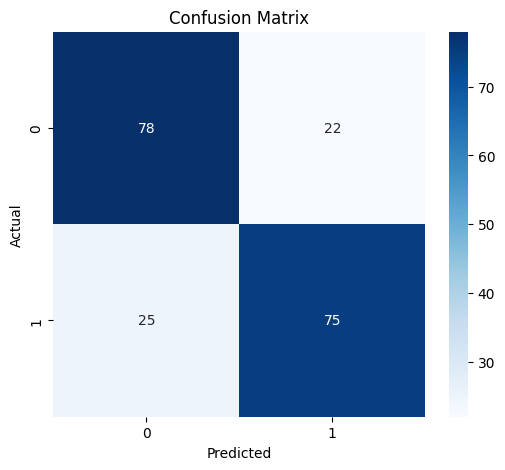

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **Step 13 — Test Your Own Reviews**

In [32]:
new_reviews = [
    "Great",
    "The service was terrible and disappointing",
    "Very good experience",
    "I hate this product"
]

In [33]:
new_reviews_clean = [
    clean_text(review)
    for review in new_reviews
]

In [34]:
new_reviews_tfidf = tfidf.transform(new_reviews_clean)

In [35]:
predictions = model.predict(new_reviews_tfidf)

for review, prediction in zip(new_reviews, predictions):
    print("Review:", review)
    print("Prediction:", prediction)
    print()

Review: Great
Prediction: 1

Review: The service was terrible and disappointing
Prediction: 0

Review: Very good experience
Prediction: 1

Review: I hate this product
Prediction: 0



# **Step 14 — Find Important Words**

In [28]:
feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0]

important_words = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})

In [29]:
positive_words = important_words.sort_values(
    "Coefficient",
    ascending=False
).head(10)

positive_words

,Word,Coefficient
516,great,3.628315
511,good,2.605480
401,excellent,1.949168
1324,well,1.872389
699,love,1.729422
98,best,1.705150
904,price,1.462784
783,nice,1.462327
360,easy,1.452219
208,comfortable,1.446023


In [30]:
negative_words = important_words.sort_values(
    "Coefficient"
).head(10)

negative_words

,Word,Coefficient
890,poor,-1.611873
80,bad,-1.365550
312,disappointed,-1.307593
1363,worst,-1.267072
328,doesnt,-1.217407
330,dont,-1.145213
448,first,-1.136362
559,horrible,-1.068364
1312,waste,-1.047169
138,buy,-0.993084


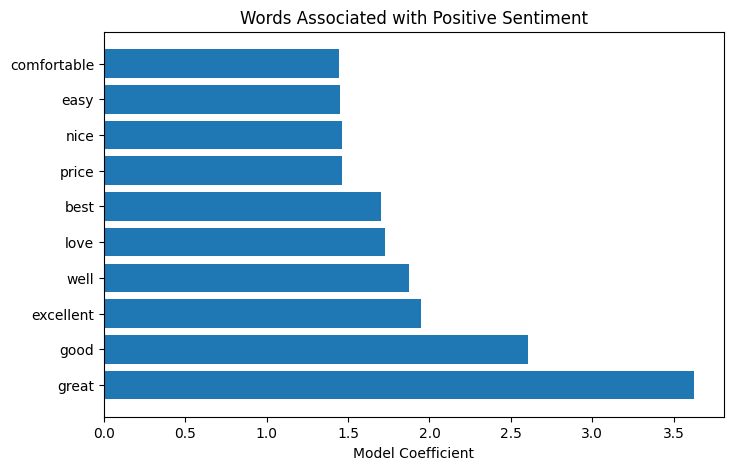

In [31]:
plt.figure(figsize=(8,5))

plt.barh(
    positive_words["Word"],
    positive_words["Coefficient"]
)

plt.title("Words Associated with Positive Sentiment")
plt.xlabel("Model Coefficient")

plt.show()